In [1]:
#model_Evdataset_tuning

base_tom = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/REPORT_short_input_basemodel_cot-False.json"
base_prag = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/pub_results_zero.csv"
prag_tom_sft = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/REPORT_short_input_prag_cot-False.json"
tom_tom_sft = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/REPORT_short_input_ToM_fine_tuned_cot-False.json"
prag_prag_sft = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/pub_results_prag.csv"
tom_prag_sft = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/pub_results_tom.csv"
tom_prag_dpo = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/DPO/results/pub_results_tom.csv"
prag_prag_dpo = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/DPO/results/pub_results_prag.csv"
prag_tom_dpo = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/DPO/results/REPORT_short_input_pragmatics_dpo_cot-False.json"
tom_tom_dpo = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/DPO/results/REPORT_short_input_ToM_dpo_cot-False.json"

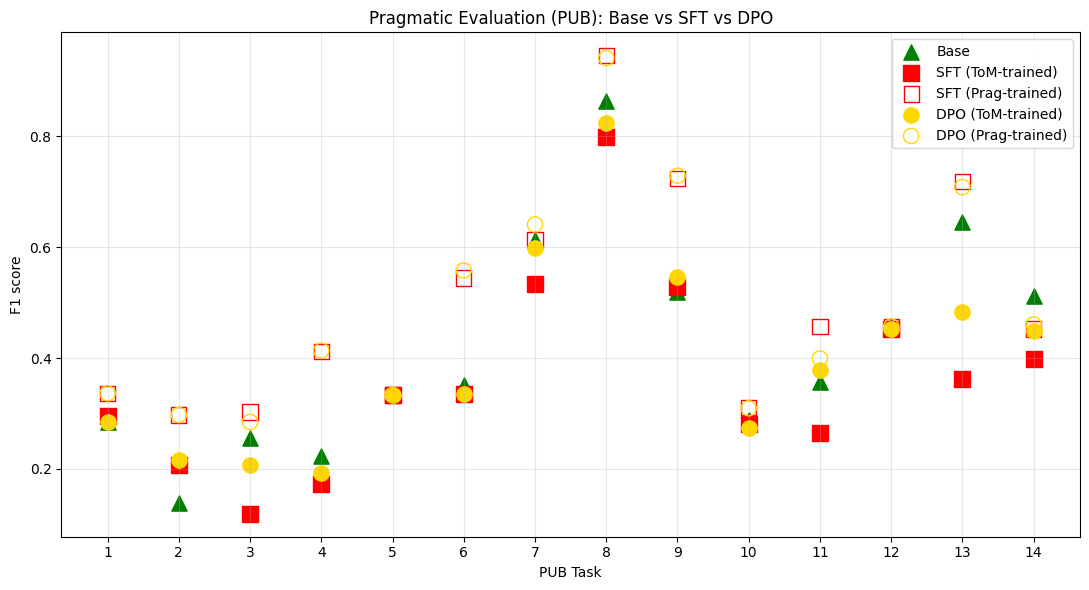

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load PUB results
# -----------------------
def load_pub_tasks(path):
    df = pd.read_csv(path)
    df["TaskID"] = df["Task"].str.extract(r"(\d+)").astype(int)
    return df.sort_values("TaskID")["F1"].values


base_f1 = load_pub_tasks(base_prag)

tom_sft_f1 = load_pub_tasks(tom_prag_sft)
prag_sft_f1 = load_pub_tasks(prag_prag_sft)

tom_dpo_f1 = load_pub_tasks(tom_prag_dpo)
prag_dpo_f1 = load_pub_tasks(prag_prag_dpo)

tasks = range(1, len(base_f1) + 1)

# -----------------------
# Plot (SCATTER ONLY)
# -----------------------
plt.figure(figsize=(11, 6))

# Base — GREEN ▲ (filled)
plt.scatter(
    tasks, base_f1,
    color="green",
    marker="^",
    s=120,
    label="Base"
)

# SFT — RED ■
plt.scatter(
    tasks, tom_sft_f1,
    color="red",
    marker="s",
    s=120,
    label="SFT (ToM-trained)"
)
plt.scatter(
    tasks, prag_sft_f1,
    facecolors="none",
    edgecolors="red",
    marker="s",
    s=120,
    label="SFT (Prag-trained)"
)

# DPO — YELLOW ●
plt.scatter(
    tasks, tom_dpo_f1,
    color="gold",
    marker="o",
    s=120,
    label="DPO (ToM-trained)"
)
plt.scatter(
    tasks, prag_dpo_f1,
    facecolors="none",
    edgecolors="gold",
    marker="o",
    s=120,
    label="DPO (Prag-trained)"
)

# -----------------------
# Formatting
# -----------------------
plt.xticks(tasks)
plt.xlabel("PUB Task")
plt.ylabel("F1 score")
plt.title("Pragmatic Evaluation (PUB): Base vs SFT vs DPO")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


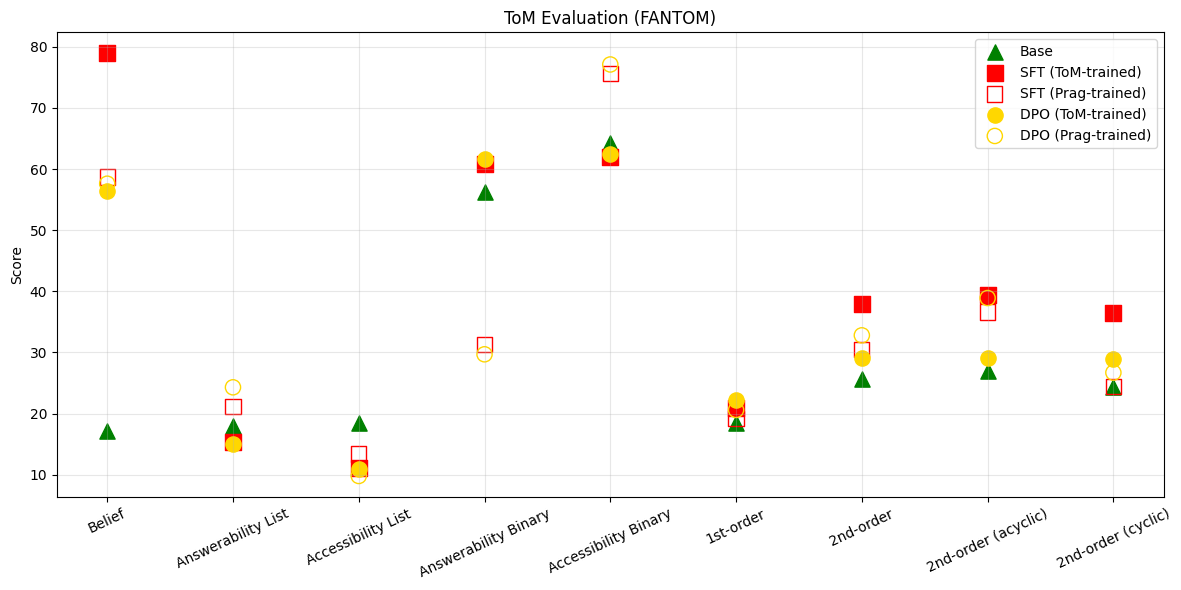

In [3]:
import json
import matplotlib.pyplot as plt

# -----------------------
# Metrics
# -----------------------
TOM_METRICS = [
    "inaccessible:belief:multiple-choice",
    "inaccessible:answerability:list",
    "inaccessible:info_accessibility:list",
    "inaccessible:answerability:binary-f1",
    "inaccessible:info_accessibility:binary-f1",
    "inaccessible:first-order",
    "inaccessible:second-order",
    "inaccessible:second-order:acyclic",
    "inaccessible:second-order:cyclic",
]

METRIC_LABELS = [
    "Belief",
    "Answerability List",
    "Accessibility List",
    "Answerability Binary",
    "Accessibility Binary",
    "1st-order",
    "2nd-order",
    "2nd-order (acyclic)",
    "2nd-order (cyclic)",
]


# -----------------------
# Loader
# -----------------------
def load_tom_metrics(path):
    path = str(path)

    if path.endswith(".json"):
        with open(path) as f:
            data = json.load(f)
        return [data[m] for m in TOM_METRICS]

    elif path.endswith(".jsonl"):
        values = {m: [] for m in TOM_METRICS}
        with open(path) as f:
            for line in f:
                obj = json.loads(line)
                for m in TOM_METRICS:
                    if m in obj:
                        values[m].append(obj[m])
        return [sum(values[m]) / len(values[m]) for m in TOM_METRICS]


# -----------------------
# Load values
# -----------------------
base_vals = load_tom_metrics(base_tom)

tom_sft_vals = load_tom_metrics(tom_tom_sft)
prag_sft_vals = load_tom_metrics(prag_tom_sft)

tom_dpo_vals = load_tom_metrics(tom_tom_dpo)
prag_dpo_vals = load_tom_metrics(prag_tom_dpo)

x = range(len(TOM_METRICS))

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(12, 6))

# Base — green ▲ (filled)
plt.scatter(
    x, base_vals,
    color="green",
    marker="^",
    s=120,
    label="Base"
)

# SFT — red ■
plt.scatter(
    x, tom_sft_vals,
    color="red",
    marker="s",
    s=120,
    label="SFT (ToM-trained)"
)
plt.scatter(
    x, prag_sft_vals,
    facecolors="none",
    edgecolors="red",
    marker="s",
    s=120,
    label="SFT (Prag-trained)"
)

# DPO — yellow ●
plt.scatter(
    x, tom_dpo_vals,
    color="gold",
    marker="o",
    s=120,
    label="DPO (ToM-trained)"
)
plt.scatter(
    x, prag_dpo_vals,
    facecolors="none",
    edgecolors="gold",
    marker="o",
    s=120,
    label="DPO (Prag-trained)"
)

# -----------------------
# Formatting
# -----------------------
plt.xticks(x, METRIC_LABELS, rotation=25)
plt.ylabel("Score")
plt.title("ToM Evaluation (FANTOM)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

# -----------------------
# Paths
# -----------------------
base_prag       = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/pub_results_zero.csv"
tom_prag_sft    = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/pub_results_tom.csv"
prag_prag_sft   = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/pub_results_prag.csv"
tom_prag_dpo    = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/DPO/results/pub_results_tom.csv"
prag_prag_dpo   = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/DPO/results/pub_results_prag.csv"

# -----------------------
# Load CSVs
# -----------------------
df_base      = pd.read_csv(base_prag)
df_tom_sft   = pd.read_csv(tom_prag_sft)
df_prag_sft  = pd.read_csv(prag_prag_sft)
df_tom_dpo   = pd.read_csv(tom_prag_dpo)
df_prag_dpo  = pd.read_csv(prag_prag_dpo)

# -----------------------
# Functions
# -----------------------
def relative_improvement(base, other):
    """Compute per-task % improvement relative to the reference"""
    return 100 * (other - base) / base

def wins(base, other):
    """Count how many tasks a model outperforms the reference"""
    return sum(other > base)

def summarize_comparison(name, df_model, df_reference):
    rel = relative_improvement(df_reference["F1"], df_model["F1"])
    n_win = wins(df_reference["F1"], df_model["F1"])
    mean_f1 = df_model["F1"].mean()
    median_f1 = df_model["F1"].median()
    
    print(f"=== {name} ===")
    print(f"Tasks won vs reference: {n_win}/{len(df_reference)}")
    print(f"Mean F1: {mean_f1:.4f}, Median F1: {median_f1:.4f}")
    print(f"Per-task %ΔF1: {rel.round(2).values}\n")

# -----------------------
# Comparisons vs Base
# -----------------------
print("=== COMPARISONS vs BASE ===\n")
summarize_comparison("SFT (ToM-trained)", df_tom_sft, df_base)
summarize_comparison("SFT (Prag-trained)", df_prag_sft, df_base)
summarize_comparison("DPO (ToM-trained)", df_tom_dpo, df_base)
summarize_comparison("DPO (Prag-trained)", df_prag_dpo, df_base)

# -----------------------
# Comparisons SFT vs DPO
# -----------------------
print("=== COMPARISONS SFT vs DPO ===\n")
summarize_comparison("DPO (ToM-trained) vs SFT (ToM-trained)", df_tom_dpo, df_tom_sft)
summarize_comparison("DPO (Prag-trained) vs SFT (Prag-trained)", df_prag_dpo, df_prag_sft)

# -----------------------
# Cross-training comparisons
# -----------------------
print("=== CROSS-TRAINING COMPARISONS ===\n")
summarize_comparison("SFT (Prag-trained) vs SFT (ToM-trained)", df_prag_sft, df_tom_sft)
summarize_comparison("DPO (Prag-trained) vs DPO (ToM-trained)", df_prag_dpo, df_tom_dpo)


=== COMPARISONS vs BASE ===

=== SFT (ToM-trained) ===
Tasks won vs reference: 4/14
Mean F1: 0.3629, Median F1: 0.3341
Per-task %ΔF1: [ 3.510e+00  4.885e+01 -5.348e+01 -2.285e+01  3.000e-02 -4.450e+00
 -1.299e+01 -7.500e+00  1.540e+00 -2.460e+00 -2.602e+01 -9.000e-01
 -4.393e+01 -2.222e+01]

=== SFT (Prag-trained) ===
Tasks won vs reference: 11/14
Mean F1: 0.4931, Median F1: 0.4546
Per-task %ΔF1: [ 1.8060e+01  1.1374e+02  1.8200e+01  8.4080e+01  3.0000e-02  5.5290e+01
  0.0000e+00  9.4900e+00  3.9080e+01  7.9500e+00  2.8030e+01 -2.0000e-02
  1.1230e+01 -1.1660e+01]

=== DPO (ToM-trained) ===
Tasks won vs reference: 4/14
Mean F1: 0.3983, Median F1: 0.3571
Per-task %ΔF1: [-1.400e-01  5.590e+01 -1.906e+01 -1.360e+01  3.000e-02 -4.420e+00
 -2.510e+00 -4.550e+00  5.190e+00 -5.140e+00  6.190e+00 -9.600e-01
 -2.518e+01 -1.236e+01]

=== DPO (Prag-trained) ===
Tasks won vs reference: 12/14
Mean F1: 0.4905, Median F1: 0.4351
Per-task %ΔF1: [ 1.7990e+01  1.1388e+02  1.1210e+01  8.4880e+01  3.0000

In [5]:
import json
import numpy as np

# -----------------------
# Paths
# -----------------------
base_tom_path       = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/REPORT_short_input_basemodel_cot-False.json"
tom_sft_path        = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/REPORT_short_input_ToM_fine_tuned_cot-False.json"
prag_sft_path       = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/SFT/results/REPORT_short_input_prag_cot-False.json"
tom_dpo_path        = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/DPO/results/REPORT_short_input_ToM_dpo_cot-False.json"
prag_dpo_path       = "/home/agnese.lombardi/progetto/ToM_Prag_comparison_bozza/DPO/results/REPORT_short_input_pragmatics_dpo_cot-False.json"
# -----------------------
# Metrics to compare
# -----------------------
FANTOM_METRICS = [
      "inaccessible:belief:multiple-choice",
    "inaccessible:answerability:list",
    "inaccessible:info_accessibility:list",
    "inaccessible:answerability:binary-f1",
    "inaccessible:info_accessibility:binary-f1",
    "inaccessible:first-order",
    "inaccessible:second-order",
    "inaccessible:second-order:acyclic",
    "inaccessible:second-order:cyclic",
]

# -----------------------
# Load metrics
# -----------------------
def load_fantom_metrics(path):
    with open(path) as f:
        data = json.load(f)
    return np.array([data[m] for m in FANTOM_METRICS])

base_vals   = load_fantom_metrics(base_tom_path)
tom_sft_vals = load_fantom_metrics(tom_sft_path)
prag_sft_vals = load_fantom_metrics(prag_sft_path)
tom_dpo_vals = load_fantom_metrics(tom_dpo_path)
prag_dpo_vals = load_fantom_metrics(prag_dpo_path)

# -----------------------
# Functions
# -----------------------
def relative_delta(reference, other):
    return other - reference

def wins(reference, other):
    return sum(other > reference)

def summarize_fantom(name, values, reference, metrics=FANTOM_METRICS):
    delta = relative_delta(reference, values)
    n_win = wins(reference, values)
    mean_val = np.mean(values)
    median_val = np.median(values)
    
    print(f"=== {name} ===")
    print(f"Metrics won vs reference: {n_win}/{len(metrics)}")
    print(f"Mean value: {mean_val:.4f}, Median value: {median_val:.4f}")
    print(f"Per-metric Δ: {delta.round(2)}\n")

# -----------------------
# Comparisons vs Base
# -----------------------
print("=== COMPARISONS vs BASE ===\n")
summarize_fantom("SFT (ToM-trained)", tom_sft_vals, base_vals)
summarize_fantom("SFT (Prag-trained)", prag_sft_vals, base_vals)
summarize_fantom("DPO (ToM-trained)", tom_dpo_vals, base_vals)
summarize_fantom("DPO (Prag-trained)", prag_dpo_vals, base_vals)

# -----------------------
# SFT vs DPO
# -----------------------
print("=== COMPARISONS SFT vs DPO ===\n")
summarize_fantom("DPO (ToM-trained) vs SFT (ToM-trained)", tom_dpo_vals, tom_sft_vals)
summarize_fantom("DPO (Prag-trained) vs SFT (Prag-trained)", prag_dpo_vals, prag_sft_vals)

# -----------------------
# Cross-training comparisons
# -----------------------
print("=== CROSS-TRAINING COMPARISONS ===\n")
summarize_fantom("SFT (Prag-trained) vs SFT (ToM-trained)", prag_sft_vals, tom_sft_vals)
summarize_fantom("DPO (Prag-trained) vs DPO (ToM-trained)", prag_dpo_vals, tom_dpo_vals)


=== COMPARISONS vs BASE ===

=== SFT (ToM-trained) ===
Metrics won vs reference: 6/9
Mean value: 40.3111, Median value: 37.9000
Per-metric Δ: [61.8 -2.5 -7.3  4.6 -2.3  2.5 12.3 12.5 12. ]

=== SFT (Prag-trained) ===
Metrics won vs reference: 6/9
Mean value: 34.5444, Median value: 30.5000
Per-metric Δ: [ 41.6   3.3  -5.  -24.9  11.3   0.8   4.9   9.7   0. ]

=== DPO (ToM-trained) ===
Metrics won vs reference: 6/9
Mean value: 35.1000, Median value: 29.1000
Per-metric Δ: [39.3 -2.9 -7.5  5.4 -1.8  3.9  3.5  2.2  4.6]

=== DPO (Prag-trained) ===
Metrics won vs reference: 7/9
Mean value: 35.2778, Median value: 29.7000
Per-metric Δ: [ 40.5   6.4  -8.6 -26.5  12.8   2.2   7.2  12.    2.3]

=== COMPARISONS SFT vs DPO ===

=== DPO (ToM-trained) vs SFT (ToM-trained) ===
Metrics won vs reference: 3/9
Mean value: 35.1000, Median value: 29.1000
Per-metric Δ: [-22.5  -0.4  -0.2   0.8   0.5   1.4  -8.8 -10.3  -7.4]

=== DPO (Prag-trained) vs SFT (Prag-trained) ===
Metrics won vs reference: 6/9
Mean 